In [1]:
# This is boilerplate code to correctly setup the settings to for notebook.
import os, sys
for root, dirs, files in os.walk(os.getcwd()):
    # print(root)

    if "pion-argon-xs-analysis" in root.split("/"):
        pypath = root.split("pion-argon-xs-analysis")[0] + "/pion-argon-xs-analysis/analysis"
        print(pypath)
        break

sys.path.insert(0, pypath)

from python.analysis.NotebookUtils import init_notebook
%init_notebook

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis
env: PYTHONPATH=/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis


In [2]:
from python.analysis import cross_section, Application, Master, Plots
from python.analysis.MaCh3FitOutput import MaCh3FitOutput
from apps import cex_cross_section
import numpy as np
import awkward as ak
import scipy.stats as stats


cross_section.PlotStyler(dark=True)

In [3]:
config = "work/analysis_new_selection/analysis_config_new_selection.json"
args = Application.ApplicationArguments.ResolveConfig(Master.LoadConfiguration(config))
ais = {k : cross_section.LoadObject(v) for k, v in args.analysis_input.items() if "mc" in k}

In [4]:
args.mach3

{'KE_int_binning': {'range': [0, 2400], 'bin_width': 50},
 'fit_output': '/home/bhuller/mach3_dune/MaCh3_DUNE/Test.root'}

In [5]:
postfit_results = MaCh3FitOutput("/home/bhuller/mach3_dune/MaCh3_DUNE/Test.root", args.process_definitions, args.energy_slices)

book = Plots.PlotBook("xs_extract", True, None)


pdf xs_extract.pdf has been opened


In [6]:
from matplotlib.patches import Rectangle

def HighlightCells(ax, mask):
    rows, cols = np.where(mask)

    for row, col in zip(rows, cols):
        ax.add_patch(
            Rectangle(
                (col - 0.5, row - 0.5),
                1,
                1,
                fill=False,
                edgecolor="red",
                linewidth=2,
            )
        )
    return

def PlotMatrix(matrix : np.ndarray, highlight : np.ndarray = None, title : str = None):
    fig, ax = Plots.plt.subplots()

    im = ax.imshow(matrix)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("mean value")

    ticks = ["Overflow"] + list(args.energy_slices.num) + ["Underflow"]
    Plots.plt.grid(False)
    Plots.plt.xticks(range(len(ticks)), ticks)
    Plots.plt.yticks(range(len(ticks)), ticks)
    Plots.plt.title(title)

    if highlight is not None:
        HighlightCells(ax, highlight)
    return

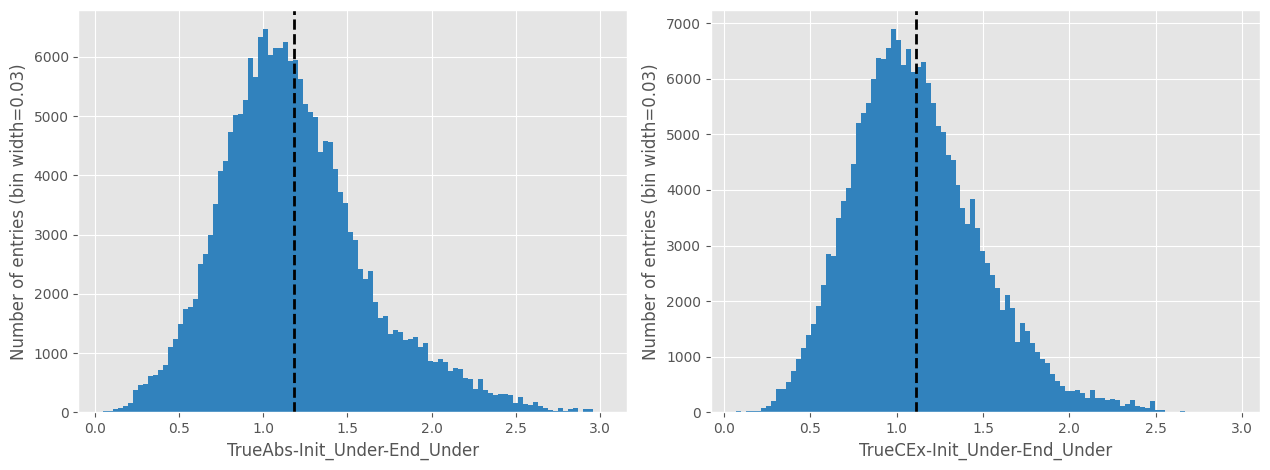

In [7]:
for i in Plots.MultiPlot(2):
    k, v = list(postfit_results.posteriors.items())[i]
    Plots.PlotHist(v, xlabel = k, newFigure=False)
    Plots.plt.axvline(np.mean(v), color = "k", linewidth=2, linestyle = "--")
book.Save()

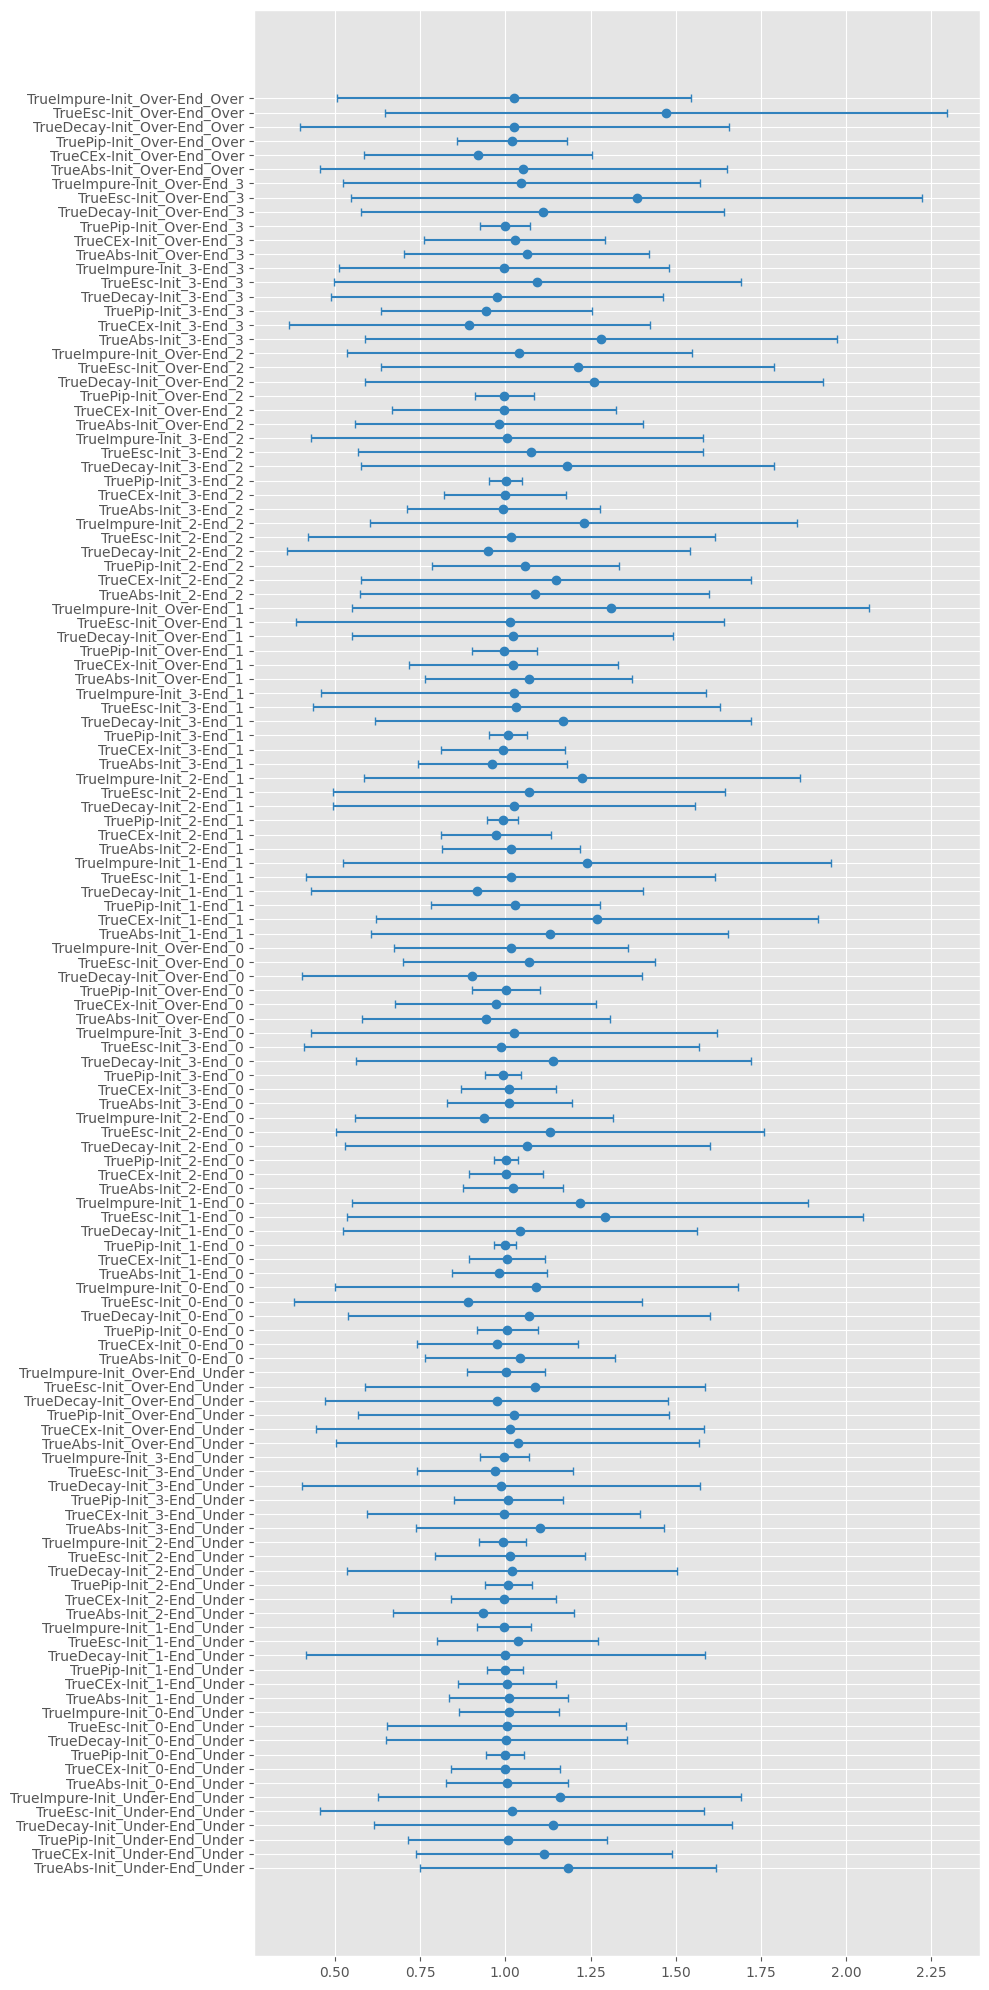

In [8]:
mean_params = {k : np.mean(v) for k, v in postfit_results.posteriors.items()}
# stderr_params = {k : abs(np.abs(stats.t.interval(0.68, df = len(v)-1, loc=np.mean(v), scale=np.std(v, ddof=1) / np.sqrt(len(v)))) - np.mean(v)) for k, v in postfit_results.posteriors.items()}

stderr_params = {k : np.std(v, ddof=1) for k, v in postfit_results.posteriors.items()}


Plots.plt.figure(figsize=[10, 20])
Plots.Plot(list(mean_params.values()), range(len(mean_params)), xerr=np.array(list(stderr_params.values())).T, newFigure=False, marker="o", linestyle="")
Plots.plt.yticks(range(len(mean_params)), list(mean_params.keys()), rotation=0)
Plots.plt.tight_layout()
book.Save()

In [17]:
post_tensor = postfit_results.posterior_tensors()

prefit_cross_sections = cex_cross_section.extract_cross_sections(ais["mc_cheated"], args.energy_slices, args.process_definitions, args.fiducial_volume, None, True)
postfit_cross_sections = cex_cross_section.extract_cross_sections(ais["mc_cheated"], args.energy_slices, args.process_definitions, args.fiducial_volume, post_tensor, True)


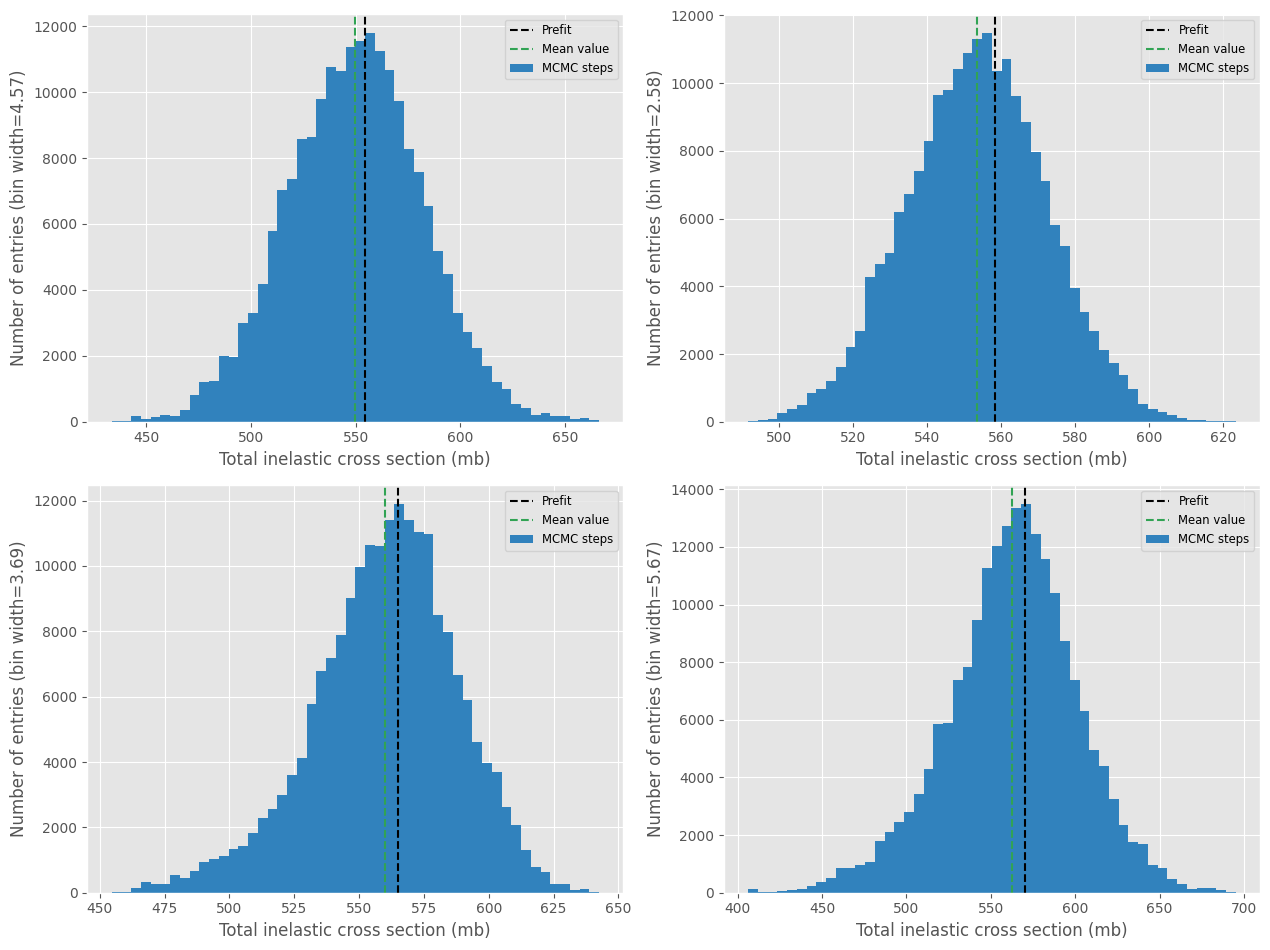

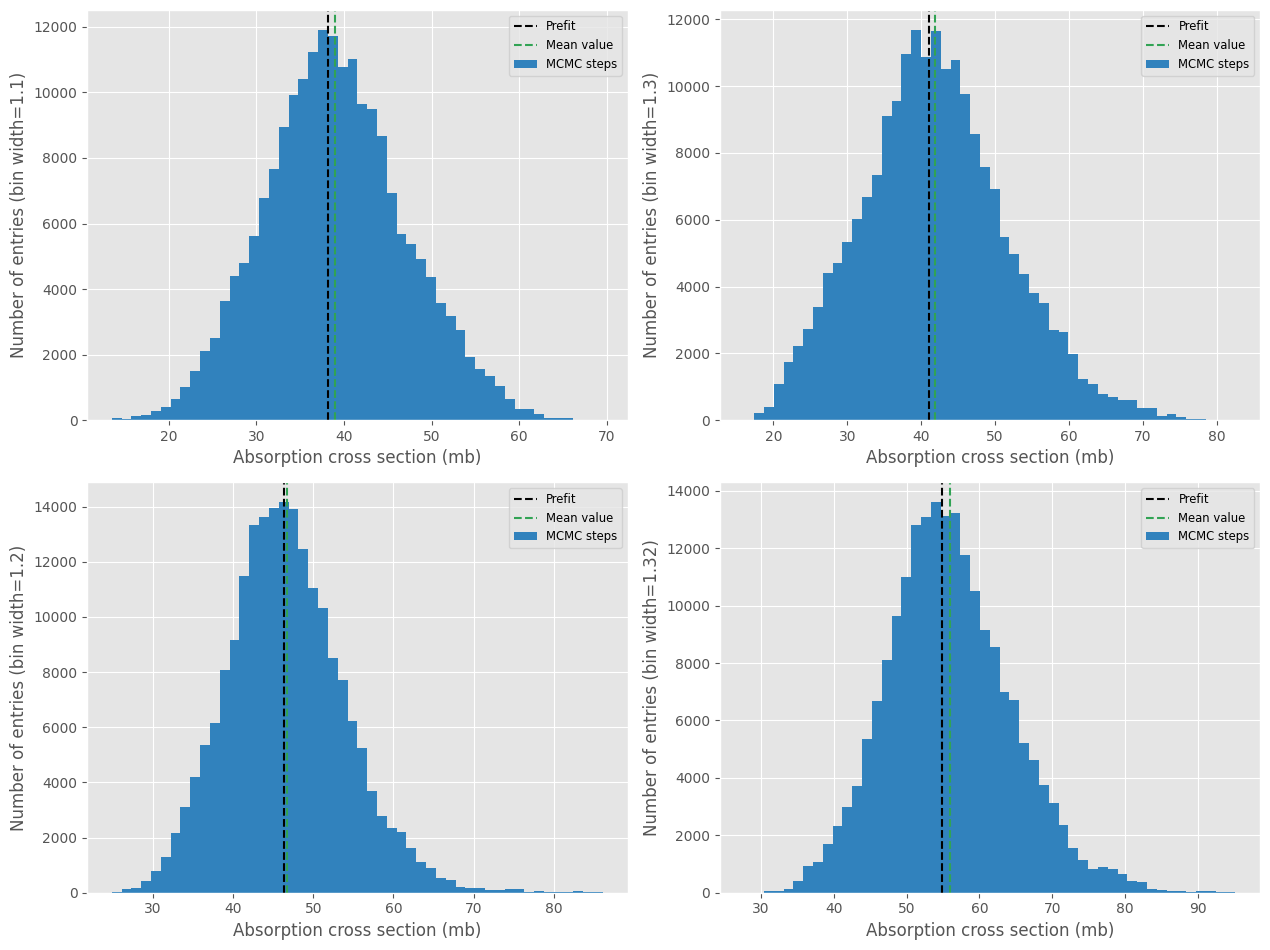

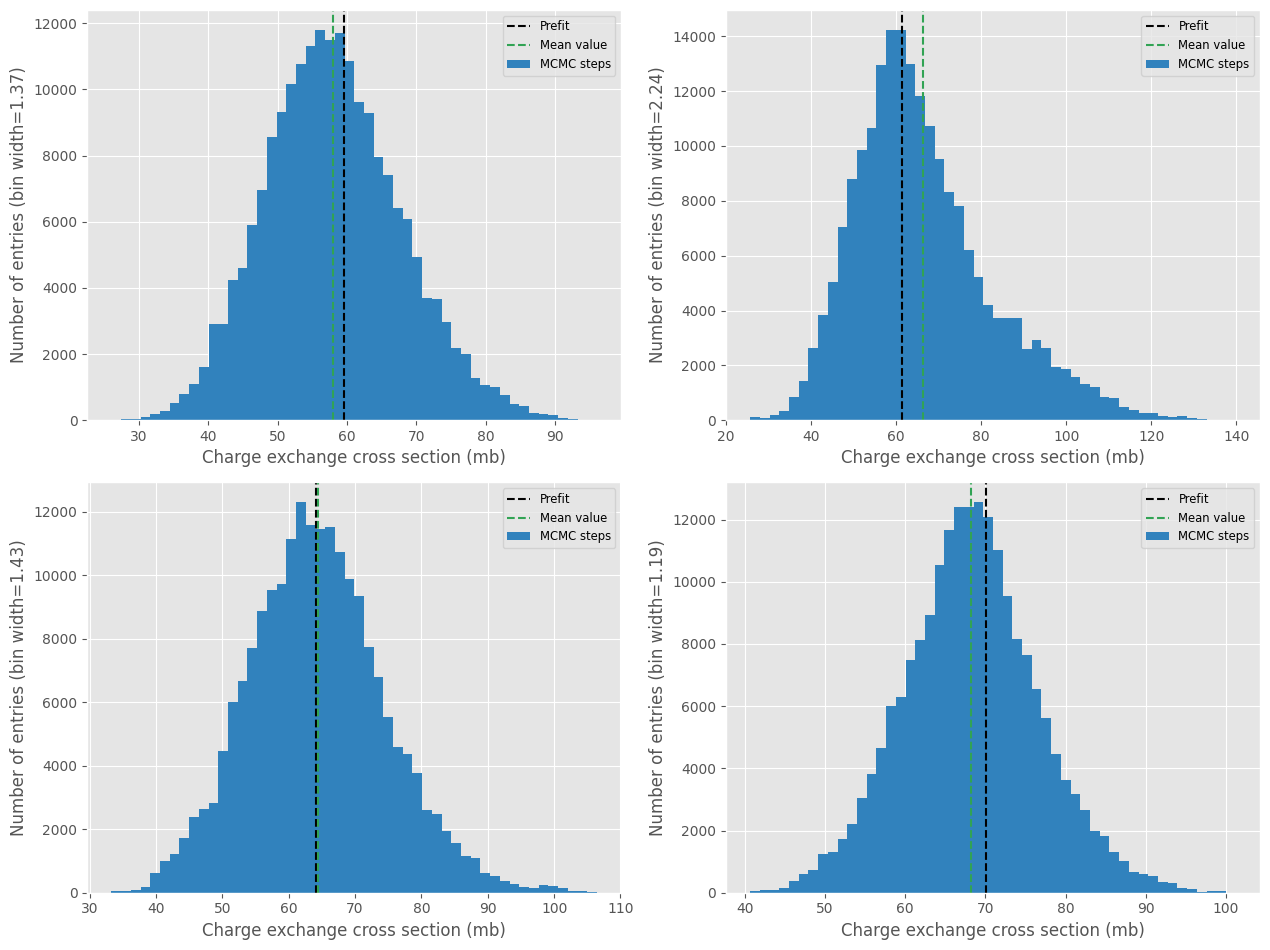

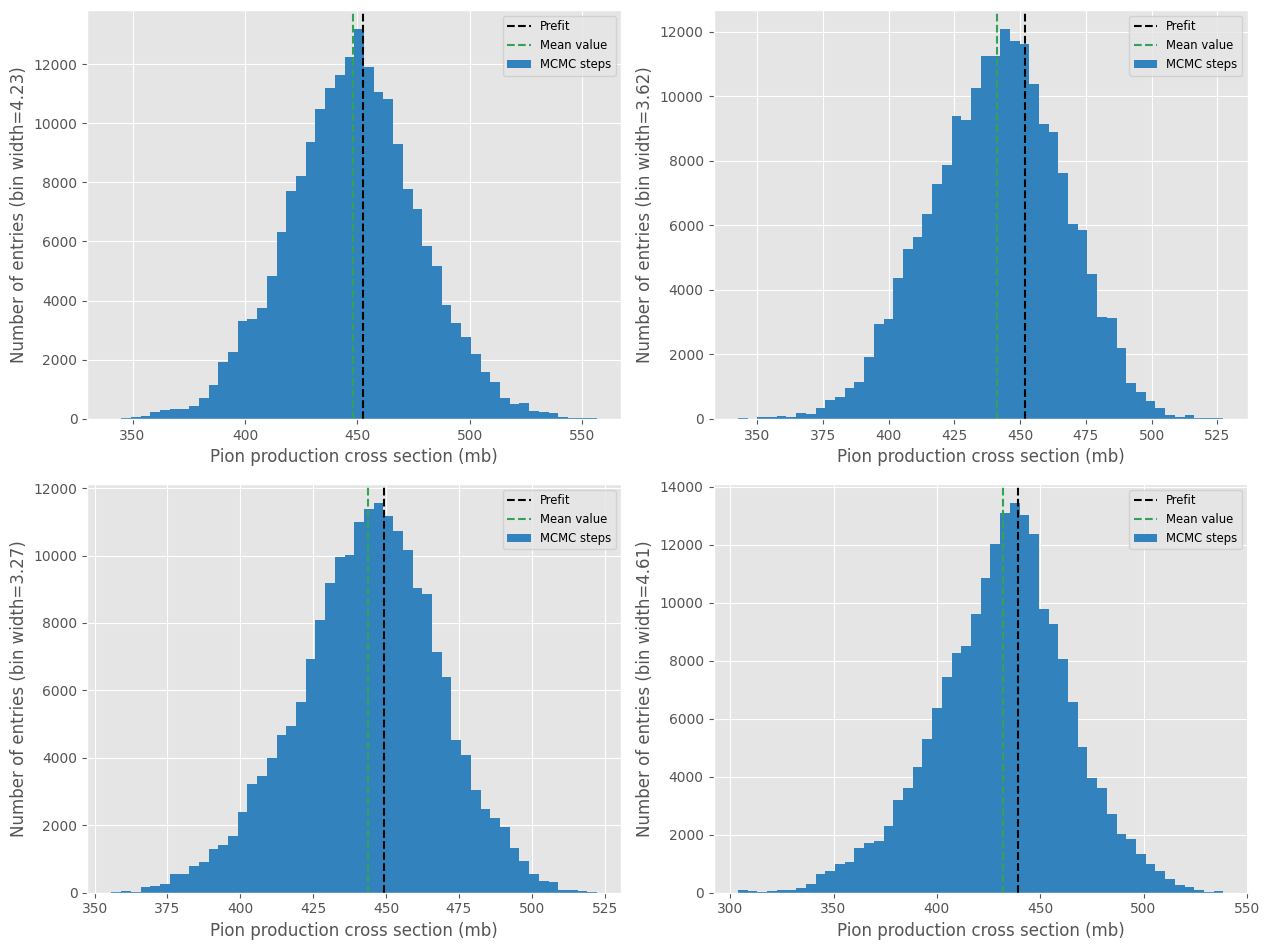

In [18]:
for k, v in postfit_cross_sections.items():
    cross_section.PlotCrossSectionSteps(v, k, prefit_cross_sections[k])

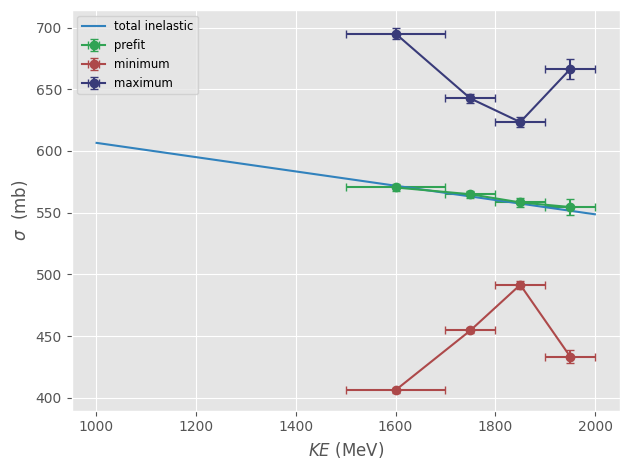

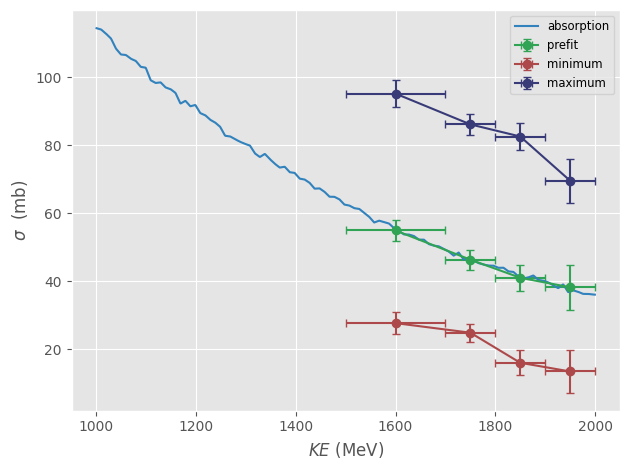

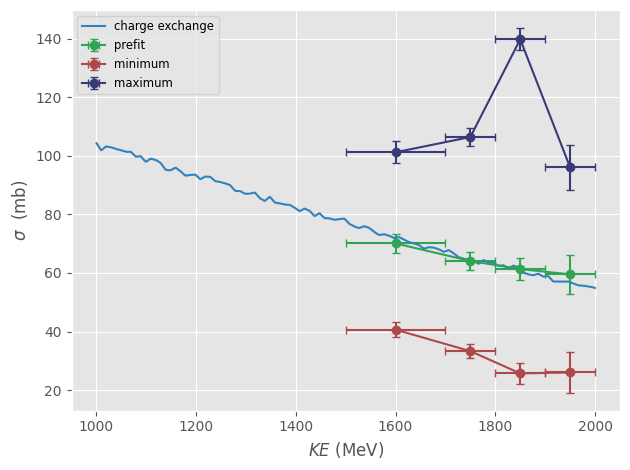

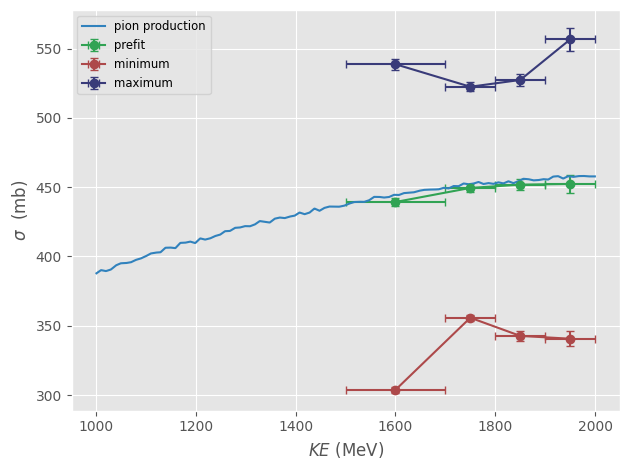

In [19]:
for k, v in postfit_cross_sections.items():
    cross_section.PlotCrossSectionMinMax(v, prefit_cross_sections[k], k, args.energy_slices)
    book.Save()

Means and confidence intervals

In [13]:
book = Plots.PlotBook("xs_extract_ff_min_fv", False, None)

In [20]:
cl = 0.68

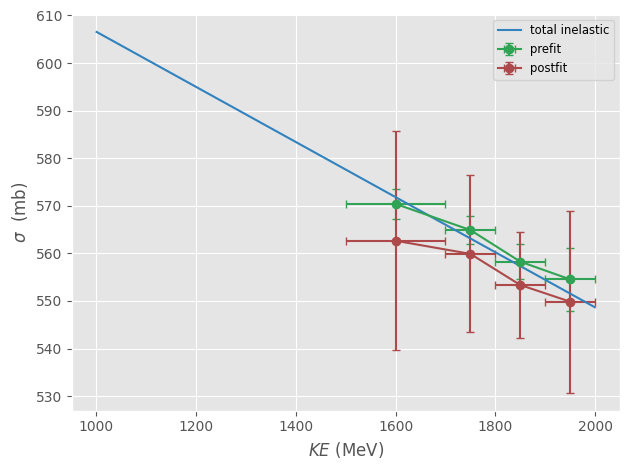

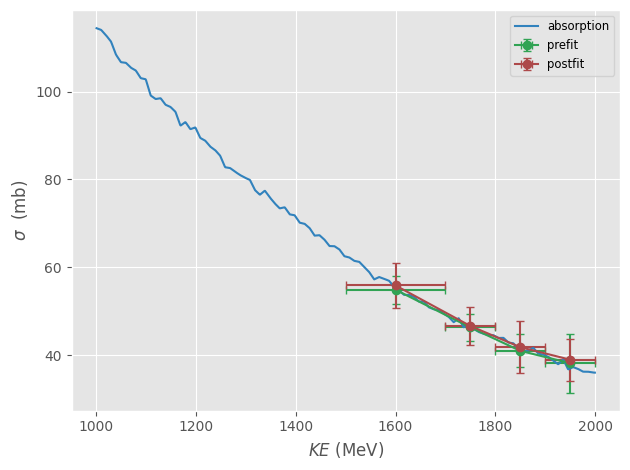

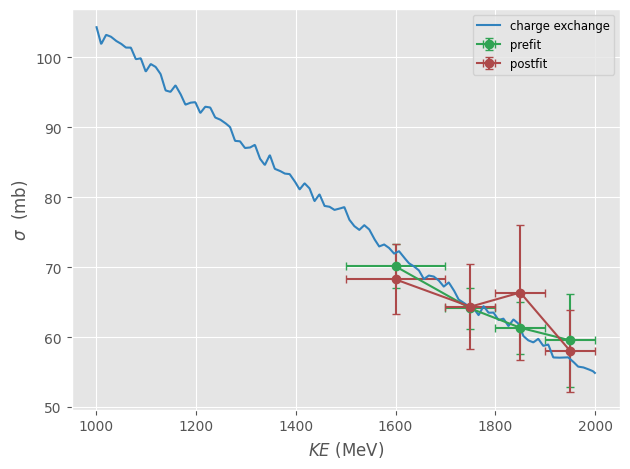

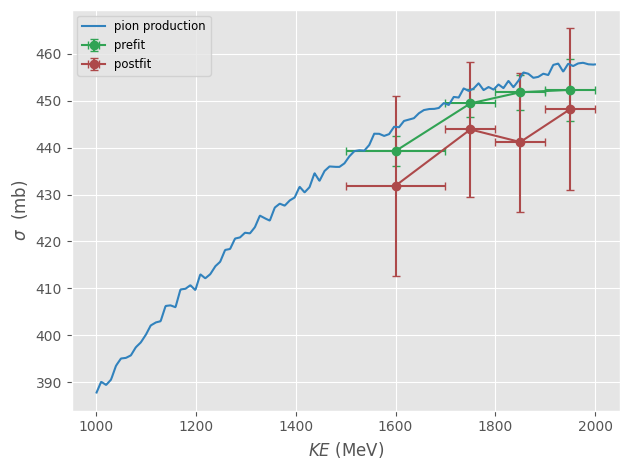

In [21]:
for k, v in postfit_cross_sections.items():
    cross_section.PlotCrossSectionCL(v, prefit_cross_sections[k], k, args.energy_slices, cl)
    book.Save()

In [16]:
book.close()

/home/bhuller/xs_analysis//pion-argon-xs-analysis/analysis/python/analysis/Plots.py:897: UserWarning: pdf has not been opened.
  warnings.warn("pdf has not been opened.")
